### Import Libraries

In [1]:
!pip install gensim
import sys, os, re, json, joblib, getpass, warnings, time ,importlib
from pathlib import Path
from functools import lru_cache
from collections import Counter
import backend.services.text_normalizer as tn
from backend.services.text_normalizer import normalize_plain

import ast

# make the project's `backend` package importable from notebooks/
if ".." not in sys.path:
    sys.path.insert(0, "..")

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

# --- core data / math ---
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import re

# --- visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import NMF
from sklearn.decomposition import LatentDirichletAllocation

# --- NLP ---
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from gensim.models import Word2Vec
from gensim.models.phrases import Phrases, Phraser
#Vectorize with raw counts on unstemmed text
from sklearn.feature_extraction.text import CountVectorizer

# --- ML ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# --- embeddings / GenAI ---
from sentence_transformers import SentenceTransformer
from google import genai

print(sys.executable)
print("All libraries loaded.")

D:\Downloads\nlp-finalproject-cinesquad-main\.venv\Scripts\python.exe
All libraries loaded.


## 2. Data Preprocessing & Normalization

### 2.1 Data Preprocessing
The json file : reviews.json is loaded & inspected.Each item_id corresponds to a unique movie and each txt to a review about this movie.Then a labeled column ( positive or negative ) is created according to the existence of ranking in the context of txt column. If no ranking of the form( 8/10 , eight out of ten, eight/ten ) is found , then the review is deleted from the labeled dataset.

### Labeling

In [2]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Google Drive only — OneDrive does not mount here, so the file must be
    # copied into Drive first. Prompts for auth once per session.
    from google.colab import drive
    drive.mount("/content/drive")
    reviews_path = "/content/drive/MyDrive/reviews.json"   # adjust to your layout
else:
    # Local kernel runs from notebooks/, so the data folder is one level up
    reviews_path = os.path.join(os.getcwd(), os.path.pardir,
                                "movie_dataset_public_final", "raw", "reviews.json")

print("Reading:", os.path.abspath(reviews_path), "| exists:", os.path.exists(reviews_path))

# Inspect structure without loading all 2.6M records (JSON Lines: one object per line)
with open(reviews_path, encoding="utf-8") as f:
    sample = [json.loads(next(f)) for _ in range(5)]

print("fields per record:", list(sample[0].keys()))
pd.DataFrame(sample)

Reading: D:\Downloads\nlp-finalproject-cinesquad-main\movie_dataset_public_final\raw\reviews.json | exists: True
fields per record: ['item_id', 'txt']


,item_id,txt
0,172063,"one-shot record of a belly dancer; ""Carmencita..."
1,95541,Banging Away..; Thomas Edison and William K.L....
2,7065,unbelievable; I cannot understand how anyone c...
3,3739,I'm still starry-eyed from it; I saw this last...
4,1562,Failed on every Front; Joel Schumacher who did...


In [3]:
# ============================================================
# LABELING  -  read per-review scores written in the text
# Handles:  8/10 | 8.5/10 | 8 out of 10 | 7 out of ten | eight out of ten
# ============================================================

WORD_NUMS = {"one":1,"two":2,"three":3,"four":4,"five":5,
             "six":6,"seven":7,"eight":8,"nine":9,"ten":10}

# score: digits (optional decimal) OR a spelled-out word
NUM   = r"(?:\d{1,2}(?:\.\d+)?|one|two|three|four|five|six|seven|eight|nine|ten)"
# separator: "/" or "out of"
SEP   = r"\s*(?:/|out\s+of)\s*"
# denominator: 10 or "ten"; \b stops "10 out of 100" reading as 10/10
DENOM = r"(?:10|ten)\b"
rating_pattern = re.compile(rf"({NUM}){SEP}{DENOM}", re.IGNORECASE)

def to_score(tok):
    t = tok.lower()
    return float(WORD_NUMS[t]) if t in WORD_NUMS else float(t)

labeled, drop_reasons, total = [], Counter(), 0
with open(reviews_path, encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        total += 1
        record  = json.loads(line)
        matches = rating_pattern.findall(record["txt"])

        if not matches:
            drop_reasons["no_match"] += 1
            continue

        # count DISTINCT values, not raw matches: "9/10 ... nine out of ten" -> {9.0}, keep it
        try:
            scores = {to_score(m) for m in matches}
        except (ValueError, KeyError):
            drop_reasons["unparseable"] += 1
            continue
        if len(scores) > 1:
            drop_reasons["conflicting_scores"] += 1   # e.g. "8/10 acting, 3/10 plot"
            continue

        score = scores.pop()
        if score < 1 or score > 10:
            drop_reasons["out_of_range"] += 1
            continue
        if score >= 7:
            label = "positive"
        elif score <= 4:
            label = "negative"
        else:
            drop_reasons["ambiguous_middle"] += 1     # 5, 6, 6.5 ...
            continue

        labeled.append({"item_id": record["item_id"], "text": record["txt"],
                        "score": score, "label": label})

print(f"Total records read: {total}")
print(f"Kept: {len(labeled)}")
print(drop_reasons)
print(Counter(r["label"] for r in labeled))
label_counts = Counter(r["label"] for r in labeled)
print(label_counts)

Total records read: 2624608
Kept: 211418
Counter({'no_match': 2342714, 'ambiguous_middle': 50493, 'conflicting_scores': 15694, 'out_of_range': 4289})
Counter({'positive': 171470, 'negative': 39948})


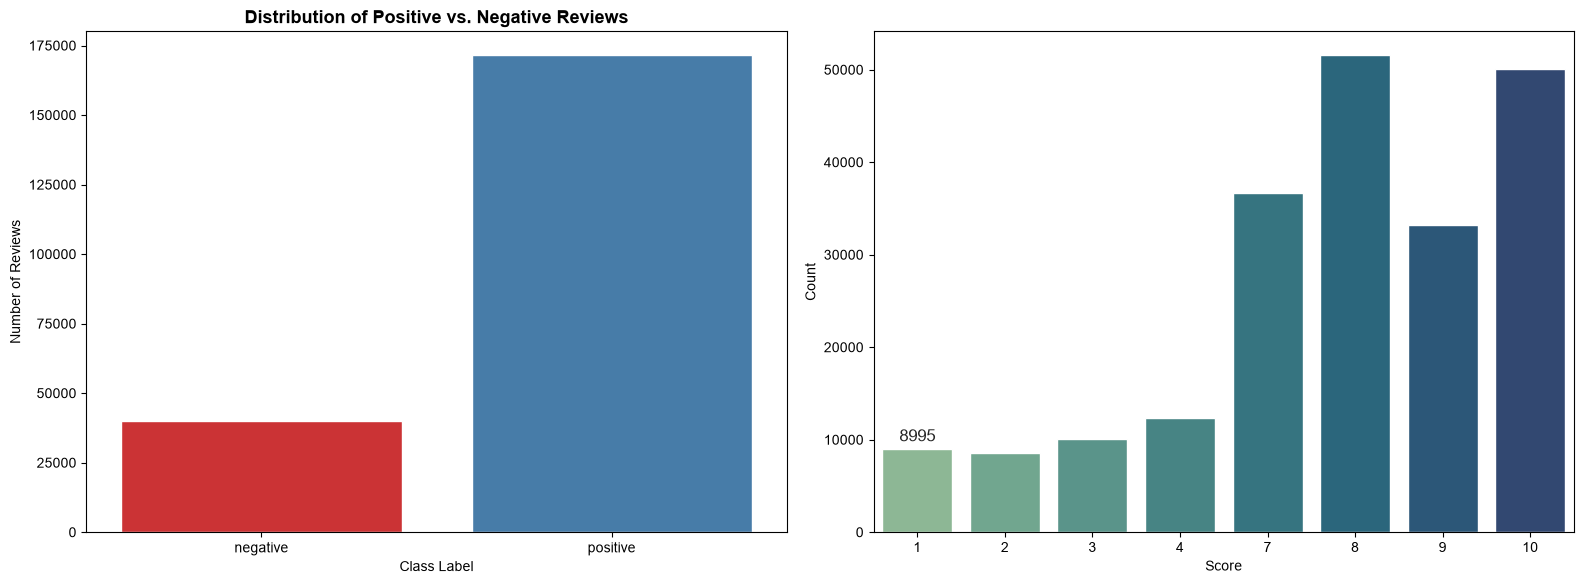

In [5]:
#========================================================
# Analyzing Dataset Class Balance and Score Distributions
#========================================================

# Set up the plotting grid (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Convert Counter data into a  DataFrame
labels_df = pd.DataFrame(list(label_counts.items()), columns=['Sentiment', 'Count'])

sns.barplot(
    x='Sentiment',
    y='Count',
    data=labels_df,
    palette='Set1',
    ax=axes[0]
)
axes[0].set_title("Distribution of Positive vs. Negative Reviews", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Number of Reviews")

# ========================================================
# Plot 2: Full Score Distribution (1-10 Breakdown)
# ========================================================
# Convert your sorted scores into a clean pandas DataFrame
scores_df = pd.DataFrame(sorted(score_counts.items()), columns=['Score', 'Count'])

scores_df['Score'] = scores_df['Score'].round().astype(int)

scores_df = scores_df.groupby('Score', as_index=False)['Count'].sum()


sns.barplot(
    x='Score',
    y='Count',
    data=scores_df,
    palette='crest', # Beautiful smooth gradient color palette
    ax=axes[1]
)
sns.barplot(x='Score', y='Count', data=scores_df, palette='crest', ax=axes[1])
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=3)

# Adjust layout cleanly so text doesn't overlap
plt.tight_layout()
plt.show()

### Review Sentiment and Score Distribution Analysis

The charts illustrate the final target variable distributions across the pruned movie review dataset:

* **Distribution of Positive vs. Negative Reviews (Left):** The binary sentiment classes exhibit a clear imbalance. Positive reviews significantly outnumber negative reviews, with positive cases exceeding 170,000 records while negative reviews hover around 39,000.
* **Full Review Score Distribution (Right):** The Score rating distribution provides granular context for this imbalance. The data is heavily skewed toward higher ratings, with  8 and 10 being the most frequent scores in the dataset.

#### Modeling Implications
1. **Class Imbalance Handling:** Because positive samples are roughly 3 to 4 times more prevalent than negative ones, standard accuracy metrics may give a false sense of performance. Evaluation metrics such as Precision, Recall, and F1-Score must be utilized to properly monitor minority class performance.
2. **Missing Neutral Classes (Scores 5 & 6):** The clear gap between scores 4 and 7 perfectly visualizes our previous data-cleaning step (`ambiguous_5_6` filter). Removing these neutral reviews successfully isolated distinct positive and negative signals, which will help the classification model converge on sharper decision boundaries.

### Data Cleaning  

In [6]:
# ============================================================
# BUILD DATAFRAME + DATA CLEANING
#   missing values, exact duplicates, short-review outliers, PII scan
# ============================================================
df = pd.DataFrame(labeled)
print("start:", len(df))

# 1. missing
print("NaN total:", int(df.isna().sum().sum()))
df = df.dropna().reset_index(drop=True)

# 2. exact-duplicate reviews (same raw text submitted more than once)
before = len(df)
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print("dropped exact duplicates:", before - len(df))

# 3. inconsistency check: same text, different label (should be 0)
conflicts = df.groupby("text")["label"].nunique()
print("texts with conflicting labels:", int((conflicts > 1).sum()))

# 4. outliers: reviews under 5 words carry almost no signal
lens = df["text"].str.split().str.len()
before = len(df)
df = df[lens >= 5].reset_index(drop=True)
print("dropped <5-word reviews:", before - len(df))

# 5. PII scan (brief requires PII be removed/handled) -- report even if zero
emails = df["text"].str.contains(r"\S+@\S+\.\S+", regex=True).sum()
phones = df["text"].str.contains(r"\b\d{3}[-.]?\d{3}[-.]?\d{4}\b", regex=True).sum()
print("emails found:", int(emails), "| phone-like:", int(phones))

print("final:", len(df))
os.makedirs("../movie_dataset_public_final/processed", exist_ok=True)
df.to_csv("../movie_dataset_public_final/processed/labeled_reviews.csv", index=False)
df.head()

start: 211418
NaN total: 0
dropped exact duplicates: 421
texts with conflicting labels: 0
dropped <5-word reviews: 0
emails found: 85 | phone-like: 13
final: 210997


,item_id,text,score,label
0,1562,Failed on every Front; Joel Schumacher who did...,3.0,negative
1,2174,An Accomplished Tim Burton Movie; A Great Idea...,8.0,positive
2,143027,"What a great change; Now, the stereotypical Di...",7.0,positive
3,2997,"Good, But Not For Everyone; A truly original e...",8.0,positive
4,7367,Brilliant. This one matches -if not out stands...,10.0,positive


## 2.2 Data Normalization
### Text Preprocessing, Normalization, and Lexical Tokenization Pipeline

###  Removal of Explicit Review Ratings (Preventing Data Leakage)

During the text preprocessing phase , a regular expression pattern was used to scan the raw text data and strip out explicit strings matching text scores (such as "8/10","8 out of 10", "eight/ten" , "eight of ten" ).
This preprocessing step is a critical requirement due to **Label Leakage**:
If left uncleaned, a machine learning model or NLP classifier will bypass the complex work of analyzing linguistic sentiment. Instead, it will simply lock onto the digits `7/10` to cheat its way to a perfect prediction during training. This creates an artificially inflated evaluation score during validation, but results in poor performance in production when evaluating real-world text that lacks an explicit score suffix.

In [7]:
# Remove the in-text rating so the model can't cheat by reading the score (label leakage).
# Same pattern as the labeler (digits/decimals/words, "/" or "out of"), no capture group.
strip_pattern = rf"{NUM}{SEP}{DENOM}"
df["text_clean"] = df["text"].str.replace(strip_pattern, " ", regex=True, flags=re.IGNORECASE)

In [8]:
# Sanity check: must be 0 -- reuse the labeler's compiled pattern so the check can't drift
remaining = df["text_clean"].str.contains(rating_pattern, regex=True).sum()
print("Rows still containing a rating pattern:", int(remaining))

Rows still containing a rating pattern: 0


### Advanced Text Normalization Pipeline

To prepare the raw movie review text for NLP modeling, an advanced normalization function (`advanced_normalize_text`) was implemented. This pipeline transforms noisy, unstructured user text into a clean sequence of meaningful words (tokens) through a multi-stage cleaning process:

#### Noise Reduction & Text Cleaning
* **HTML & URL Removal:** Strips out web artifacts such as HTML tags (`<.*?>`) and web links (`http/https/www`), which do not contribute to sentiment.
* **Social Media Filtering:** Removes user handles (`@mentions`) and hashtags (`#topic`) often found in modern text data.
* **Character Standardizing:** Drops emojis and non-standard keyboard characters by forcing ASCII encoding, and converts all characters to **lowercase**.
* **Elongated Word Fix:** Uses regular expressions to fix exaggerated repeating letters (e.g., changing `"looooove"` to `"loove"`), which helps compress varying spellings into a single recognizable word.
* **Punctuation Stripping:** Removes all numbers, special characters, and punctuation markers, keeping only raw letters (`a-z`).
* **Intelligent Stopword Filtering:** Standard English stopwords (like *"the"*, *"is"*) are removed to focus on content-heavy words. **Crucially, negation words (`not`, `no`, `never`, `nor`) are intentionally kept** in the vocabulary since removing them would destroy the core meaning of a negative review (e.g., turning *"not good"* into *"good"*).
* **Length Pruning:** Drops ultra-short words (less than 2 characters, such as *"a"* or *"i"*) to decrease vocabulary noise.
* **Stemming (Porter):** Reduces inflected forms to a common stem (`"loved"`, `"loving"`, `"loves"` → `"love"`) so the model treats them as one feature instead of three.

In [9]:
nltk.download('wordnet')

# ============================================================
# ADVANCED TEXT NORMALIZATION
# NOTE: this same function is duplicated in backend/services/text_normalizer.py
#       so the saved sentiment Pipeline can normalize raw text at serving time.
# ============================================================
negations    = {"not", "no", "never", "nor"}
custom_stops = set(ENGLISH_STOP_WORDS) - negations
lemmatizer   = WordNetLemmatizer()
stemmer      = PorterStemmer()

#@lru_cache(maxsize=200_000)
def cached_stem(token):
    return stemmer.stem(token)

# Contractions expanded BEFORE punctuation is stripped, or "don't" -> "don"+"t",
# the "t" is dropped, and the negation is lost. Order matters: can't/won't first.
CONTRACTIONS = [
    (re.compile(r"\bcan't\b", re.IGNORECASE), "can not"),
    (re.compile(r"\bwon't\b", re.IGNORECASE), "will not"),
    (re.compile(r"n't\b",     re.IGNORECASE), " not"),   # don't, isn't, didn't ...
]

# PII patterns -- must run before the @handle strip, or "@" eats the email host
RE_EMAIL   = re.compile(r"\S+@\S+\.\S+")
RE_PHONE   = re.compile(r"\b(?:\+?\d{1,3}[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b")
RE_HTML    = re.compile(r"<.*?>")
RE_URL     = re.compile(r"https?://\S+|www\.\S+")
RE_HANDLE  = re.compile(r"@\w+|#\w+")
RE_REPEAT  = re.compile(r"(.)\1{2,}")      # 3+ identical chars in a row
RE_NONALPHA = re.compile(r"[^a-z\s]")

def advanced_normalize_text(text, mode="stem"):
    """mode: 'none' | 'stem' | 'lemma'.  Returns a STRING (TfidfVectorizer wants strings)."""
    if not isinstance(text, str):
        return ""
    text = RE_HTML.sub(" ", text)                          # HTML
    text = RE_URL.sub(" ", text)                           # URLs
    text = RE_EMAIL.sub(" ", text)                         # PII: emails
    text = RE_PHONE.sub(" ", text)                         # PII: phone numbers
    text = RE_HANDLE.sub(" ", text)
    text = text.encode("ascii", "ignore").decode("ascii") # emoji / non-ASCII
    for pat, repl in CONTRACTIONS:                         # contractions (before punctuation)
        text = pat.sub(repl, text)
    text = RE_REPEAT.sub(r"\1", text)                      # "Looove" -> "Love"
    text = text.lower()
    text = RE_NONALPHA.sub(" ", text)                      # keep letters + spaces

    out = []
    for tok in text.split():
        if tok in custom_stops or len(tok) <= 1:
            continue
        if mode == "stem":
            tok = cached_stem(tok)
        elif mode == "lemma":
            tok = lemmatizer.lemmatize(tok)                # noun-mode: movies->movie
        out.append(tok)
    return " ".join(out)

not like bore not recommend


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\stamo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [10]:
print("Executing normalization (mode='stem') ...")

df["tokens"] = df["text_clean"].apply(lambda t: advanced_normalize_text(t, mode="stem"))

# a review that was only a score + stopwords normalizes to "" -> drop (empty doc, useless)
before = len(df)
df = df[df["tokens"].str.strip() != ""].reset_index(drop=True)
print("dropped empty-after-normalization:", before - len(df))

# leakage guard: near-duplicates that only collapse AFTER normalization
# (differ only by punctuation/casing). tokens is what the model trains on.
before = len(df)
df = df.drop_duplicates(subset="tokens").reset_index(drop=True)
print("dropped normalized duplicates:", before - len(df))

print("rows:", len(df))
os.makedirs("../data", exist_ok=True)
df.to_pickle("../data/labeled_stem.pkl")   # cache so a kernel restart skips the slow steps
print(df[["text", "tokens"]].head())

Executing normalization (mode='stem') ...
dropped empty-after-normalization: 0
dropped normalized duplicates: 141
rows: 210856
                                                text  \
0  Failed on every Front; Joel Schumacher who did...   
1  An Accomplished Tim Burton Movie; A Great Idea...   
2  What a great change; Now, the stereotypical Di...   
3  Good, But Not For Everyone; A truly original e...   
4  Brilliant. This one matches -if not out stands...   

                                              tokens  
0  fail joel schumach did ok job batman movi simp...  
1  accomplish tim burton movi great idea good scr...  
2  great chang stereotyp disney channel movi hoor...  
3  good not truli origin exampl movi make concept...  
4  brilliant match not stand big lebowski quit cr...  


### Deciding on Stemming vs. Lemmatization

Same 30k stratified subsample and the same classifier for every mode; only the
morphological reduction changes. We report macro-F1 (imbalance-aware) and the
resulting vocabulary size, with bigrams and again with unigrams only.

In [11]:
# ---- Stemming vs Lemmatization vs None (30k subsample, LogReg) ----
_sub, _ = train_test_split(df, train_size=30000, random_state=42, stratify=df["label"])

def _run(ngram):
    print(f"\n== ngram_range={ngram} ==")
    for mode in ["none", "stem", "lemma"]:
        X = _sub["text_clean"].apply(lambda t: advanced_normalize_text(t, mode=mode))
        Xtr, Xte, ytr, yte = train_test_split(
            X, _sub["label"], test_size=0.2, random_state=42, stratify=_sub["label"])
        vec = TfidfVectorizer(ngram_range=ngram, min_df=5, sublinear_tf=True)
        Xtr_v, Xte_v = vec.fit_transform(Xtr), vec.transform(Xte)
        clf = LogisticRegression(max_iter=1000, class_weight="balanced").fit(Xtr_v, ytr)
        f1 = f1_score(yte, clf.predict(Xte_v), average="macro")
        print(f"  {mode:6}  macro_F1={f1:.4f}   vocab={len(vec.vocabulary_)}")

_run((1, 2))   # with bigrams
_run((1, 1))   # unigrams only -- this is where stemming's vocabulary shrink shows

# Decision: stemming gives the smallest unigram vocabulary (largest feature collapse)
# at no meaningful cost in macro-F1, so we normalize with mode="stem" everywhere.


== ngram_range=(1, 2) ==
  none    macro_F1=0.8606   vocab=94087
  stem    macro_F1=0.8579   vocab=98200
  lemma   macro_F1=0.8612   vocab=95227

== ngram_range=(1, 1) ==
  none    macro_F1=0.8500   vocab=25994
  stem    macro_F1=0.8405   vocab=17693
  lemma   macro_F1=0.8463   vocab=23218


**Decision**: no mode gives a macro-F1 advantage -- all three land within ~0.01, and stem is marginally lowest in both settings. Stemming is chosen for the
feature space, not accuracy: it collapses the unigram vocabulary by 32%
(25,994 -> 17,693), the largest reduction of the three.

###  Dataset Splitting and Stratification

To properly train and evaluate the sentiment models, the cleaned dataset was partitioned into isolated training and testing subsets using Scikit-Learn's `train_test_split`.

The function parameters were configured to ensure statistical rigor and reproducibility:

* **Features ($X$) and Target ($y$):** The input features ($X$) consist of the preprocessed word tokens (`df['tokens']`), and the target variable ($y$) is the binary sentiment class (`df['label']`).
* **Test Size (`test_size=0.2`):** The dataset was split into an **80/20 ratio**. 80% of the data is allocated to train the machine learning models, while 20% is completely held out as an unseen test set to evaluate real-world generalization performance.
* **Stratification (`stratify=df["label"]`):** This is a critical parameter due to the severe class imbalance we found in our data exploration (where positive reviews make up roughly 81% and negative reviews make up 19%). Stratification forces the split to maintain this exact 81% to 19% ratio in *both* the training set and the test set. Without this, one split might accidentally receive all the positive reviews, causing biased training or misleading test evaluations.
* **Reproducibility (`random_state=42`):** Setting a static random seed ensures that the shuffle-and-split math behaves identically every time the notebook is run, guaranteeing reproducible experiments and consistent results.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df["tokens"],           # stemmed, space-joined review text
    df["label"],            # positive / negative
    test_size=0.2,
    stratify=df["label"],   # preserve the class ratio in both splits
    random_state=42,
)
print(X_train.shape, X_test.shape)
print("train:", dict(y_train.value_counts(normalize=True).round(3)))
print("test :", dict(y_test.value_counts(normalize=True).round(3)))

(168684,) (42172,)
train: {'positive': np.float64(0.811), 'negative': np.float64(0.189)}
test : {'positive': np.float64(0.811), 'negative': np.float64(0.189)}


## 3 Feature Engineering (Embeddings) & Text Visualization

### 3.1
### Justification for Choosing TF-IDF
* **Explicit Keyword Weighting**: Automatically calculates and scales up the mathematical importance of distinct "clue" words (like terrible or excellent) while suppressing common background noise words.
* **Linear Separability**: Creates a high-dimensional, sparse matrix that perfectly matches the mathematical strengths of linear classifiers (e.g., Logistic Regression, SVM), allowing them to draw clean decision boundaries with low computational overhead.
 ### Adding $N$-grams
* **Preserves Context**: Captures word order by grouping adjacent pairs (e.g., "not good", "highly recommend") instead of treating words completely in isolation. Crucial for accurate text classification because it keeps negative modifiers attached to their targets, preventing the model from misinterpreting a flipped sentiment or topic.

In [13]:
# TF-IDF features.
# advanced_normalize_text already returns space-joined STRINGS, so no list->str step.
# No stop_words= : we already filtered, and sklearn's list would strip our negations.
vectorizer = TfidfVectorizer(
    max_features=40000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True,
)
X_train_tfidf = vectorizer.fit_transform(X_train)   # fit on TRAIN only
X_test_tfidf  = vectorizer.transform(X_test)        # transform only -> no leakage

print(X_train_tfidf.shape, X_test_tfidf.shape)
print("vocab size:", len(vectorizer.vocabulary_))

(168684, 40000) (42172, 40000)
vocab size: 40000


### 3.2 Building the Top-$N$ Similar Words Solution.

In [14]:
# ============================================================
# 3.2  Top-N similar words  ->  Word2Vec (with bigram phrases)
# Trained on UNSTEMMED text so results are readable ("movie", not "movi").
# ============================================================

# tokenise text_clean without stemming (mode="none" keeps real English words)
w2v_sentences = [advanced_normalize_text(t, mode="none").split() for t in df["text_clean"]]

# learn common bigrams ("special_effects", "waste_time") and fold them in as tokens
bigram = Phraser(Phrases(w2v_sentences, min_count=20, threshold=10))
w2v_sentences = [bigram[s] for s in w2v_sentences]

w2v = Word2Vec(
    w2v_sentences,
    vector_size=100,   # embedding dimension
    window=5,          # context window
    min_count=5,       # ignore very rare words
    workers=4,
    seed=42,
)
print("vocab:", len(w2v.wv))

def similar_words(word, n=8):
    word = word.lower()
    if word not in w2v.wv:
        print(f"'{word}' not in vocabulary"); return
    print(f"Top {n} similar to '{word}':")
    for w, s in w2v.wv.most_similar(word, topn=n):
        print(f"  {w:20} {s:.3f}")

similar_words("good")
similar_words("awful")
# Note: 'good' ~ 'bad' is expected -- Word2Vec captures CONTEXT, not sentiment,
# which is exactly why a supervised classifier is still needed for Task 1.

vocab: 90018
Top 8 similar to 'good':
  pretty_good          0.833
  great                0.810
  decent               0.776
  pretty_decent        0.754
  bad                  0.728
  okay                 0.711
  nice                 0.707
  alright              0.695
Top 8 similar to 'awful':
  terrible             0.923
  horrible             0.894
  god_awful            0.862
  atrocious            0.847
  horrendous           0.843
  abysmal              0.834
  dreadful             0.817
  appalling            0.792


### 3.3 The t-SNE Document Visualization Script

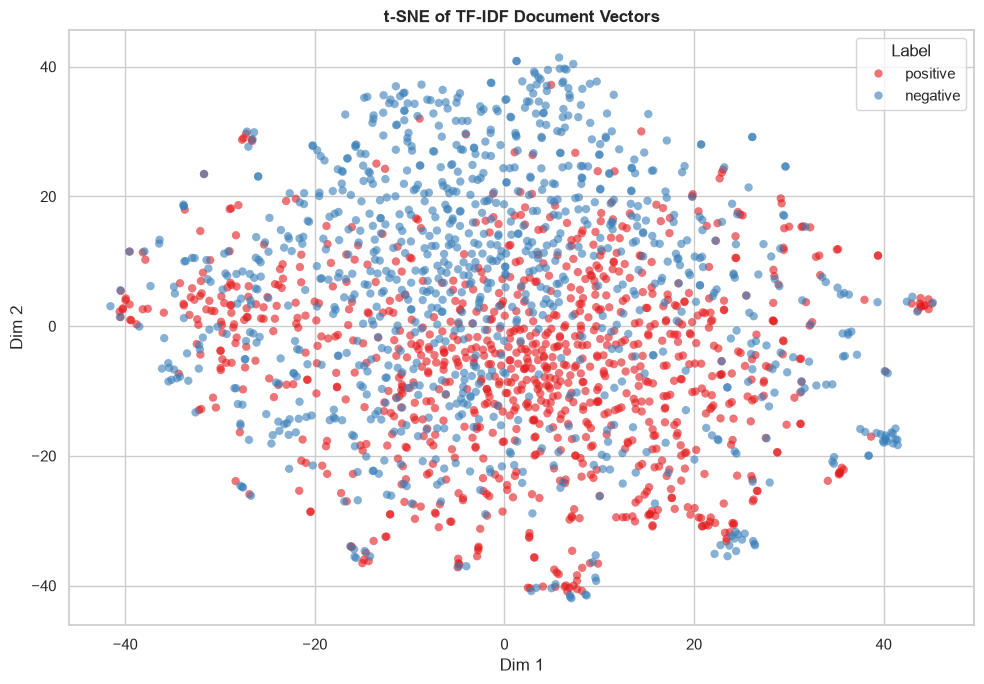

In [15]:
# ============================================================
# 3.3  t-SNE of TF-IDF document vectors (coloured by sentiment)
# SVD (sparse) 40k -> 50 dims, then t-SNE 50 -> 2. Balanced 2k sample for a readable plot.
# ============================================================
sns.set_theme(style="whitegrid")
rng = np.random.RandomState(42)
y_arr = y_train.values
pos = np.where(y_arr == "positive")[0]
neg = np.where(y_arr == "negative")[0]
m   = min(1000, len(neg))
rows = np.concatenate([rng.choice(pos, m, replace=False),
                       rng.choice(neg, m, replace=False)])

X_small = TruncatedSVD(n_components=50, random_state=42).fit_transform(X_train_tfidf[rows])
coords  = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_small)

plot_data = pd.DataFrame({"Dim 1": coords[:, 0], "Dim 2": coords[:, 1],
                          "Label": y_arr[rows]})
plt.figure(figsize=(10, 7))
sns.scatterplot(x="Dim 1", y="Dim 2", hue="Label", data=plot_data,
                palette="Set1", alpha=0.6, edgecolor="none")
plt.title("t-SNE of TF-IDF Document Vectors", fontweight="bold")
plt.tight_layout()
plt.show()

## t-SNE Diagram Analysis

t-SNE shows heavy overlap between classes, indicating that sentiment is not separable by overall document similarity in TF-IDF space. This is expected: sentiment is carried by a small number of discriminative terms rather than by global vector geometry, and a 40,000→2 projection cannot preserve the specific dimensions the linear classifier exploits. The classifier's ~0.86 macro-F1 confirms the separation exists in the full space; the overlap here reflects the limits of 2D visualization, not weak features.

## 4. Model Building

### 4.1 Unsupervised Learning

### Unsupervised Learning: Topic Modeling (Section 4.1)

We compare two unsupervised techniques to discover themes in our reviews,
without using the sentiment labels from Task 1.

**LDA (Latent Dirichlet Allocation)** — a probabilistic model: each document
is treated as a mixture of topics, and each topic as a distribution over
words. Fit on raw word counts, since LDA's generative assumptions are built
around counts rather than weighted scores.

**NMF (Non-negative Matrix Factorization)** — a linear-algebra approach: it
factorizes the document-term matrix directly into topic components, with no
generative/probabilistic assumptions. Fit on TF-IDF weights, the standard
pairing for NMF.

**Shared setup** (kept identical so the comparison is fair):
- Same 30,000-review seeded subsample.
- Same vocabulary size (5,000 words, `min_df=20`, `max_df=0.95`).
- Same domain-specific stopword list ("movie", "film", "good", "not", etc.),
  added after an initial run showed topics dominated by generic review
  language rather than genre-specific themes.
- Same number of topics (10) and random seed, for direct comparability.
- Unstemmed/unlemmatized text, so topic keywords stay human-readable.

**Why compare two methods:** LDA and NMF make different assumptions about
how topics relate to text, and can surface different (or agreeing) themes.
Comparing them tests whether discovered topics are genuine patterns in the
data or artifacts of one algorithm's assumptions.

**Findings:** Comparing the two methods, NMF clearly did a better job separating topics
than LDA did. It picked out distinct, easy-to-name themes — James Bond
films, Batman/superhero movies, horror, comedy — each with keywords that
don't really overlap with the others.

LDA's topics were messier. A few of them (topics 0, 1, 7, and 9) kept
repeating the same generic words like "best," "story," "character," and
"time," which made them hard to tell apart. Interestingly, LDA did manage
to find one really clean topic too — Batman/superhero — so it's not that
LDA can't find good topics, it just did it less consistently across the
board.

NMF works on TF-IDF scores, which already down-weight
words that show up everywhere, so the words that are actually distinctive
(character names, genres) end up mattering more. LDA works on raw word
counts, so generic review language still has a lot of pull even after we
removed our custom stopwords.

In [55]:
importlib.reload(tn)
print([n for n in dir(tn) if n.startswith("normalize")])

['normalize_batch', 'normalize_plain']


In [56]:
# NMF works better on TF-IDF than raw counts (that's the standard pairing).
# Same sample, same vocab size, same domain stopwords as LDA -- so the
# comparison between the two methods is fair.
# preprocessor= bakes normalization into the fitted vectorizer, so the backend
# can call transform() on RAW user text without re-implementing preprocessing.

tfidf_vec = TfidfVectorizer(max_df=0.95, min_df=20, max_features=5000,
                            stop_words=list(domain_stopwords),
                            preprocessor=normalize_plain)
doc_term_tfidf = tfidf_vec.fit_transform(docs_text)
vocab_tfidf = tfidf_vec.get_feature_names_out()

nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvd", max_iter=300)
nmf.fit(doc_term_tfidf)

nmf_table = top_words_table(nmf, vocab_tfidf, n_top=10)
print("=== NMF Topics ===")
for _, r in nmf_table.iterrows():
    print(f"{r['Topic']:9} | {r['Top words']}")

=== NMF Topics ===
Topic 0   | life, man, world, war, no, young, people, real, family, father
Topic 1   | bad, people, think, no, watch, say, know, ve, thought, seen
Topic 2   | horror, scary, gore, dead, zombie, house, original, genre, creepy, halloween
Topic 3   | funny, comedy, hilarious, laugh, fun, jokes, humor, comedies, funniest, laughs
Topic 4   | action, scenes, effects, sci, fi, fun, fight, special, sequences, cool
Topic 5   | best, seen, amazing, brilliant, excellent, performance, ve, time, acting, oscar
Topic 6   | bond, james, connery, moore, craig, brosnan, sean, casino, series, roger
Topic 7   | story, characters, character, interesting, quite, plot, bit, little, acting, feel
Topic 8   | love, disney, story, animation, watch, beautiful, kids, loved, music, animated
Topic 9   | book, batman, comic, read, superman, dark, books, superhero, knight, harry


In [17]:
# Fit LDA
N_TOPICS = 10   # a reasonable starting point; tune by coherence/inspection

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    learning_method="online",   # scales better than "batch" on 30k docs
    max_iter=20,
)
lda_topics = lda.fit_transform(doc_term)   # (30000, N_TOPICS) doc-topic weights
print("LDA fitted:", lda.components_.shape)   # (N_TOPICS, vocab)

LDA fitted: (10, 5000)


In [18]:
#Keyword table
def top_words_table(model, feature_names, n_top=10):
    """Return a DataFrame: one row per topic, its top-N keywords as a string."""
    rows = []
    for topic_idx, weights in enumerate(model.components_):
        top = [feature_names[i] for i in weights.argsort()[:-n_top-1:-1]]
        rows.append({"Topic": f"Topic {topic_idx}", "Top words": ", ".join(top)})
    return pd.DataFrame(rows)

lda_table = top_words_table(lda, vocab, n_top=10)
print("=== LDA Topics ===")
for _, r in lda_table.iterrows():
    print(f"{r['Topic']:9} | {r['Top words']}")

=== LDA Topics ===
Topic 0   | killer, police, jason, death, guy, kill, cop, smith, killed, violence
Topic 1   | john, bond, plays, cast, comedy, jack, played, man, james, role
Topic 2   | love, story, life, character, performance, best, role, drama, oscar, actor
Topic 3   | action, effects, star, fight, fi, sci, scenes, special, best, new
Topic 4   | think, watch, bad, people, time, say, seen, no, funny, better
Topic 5   | war, man, men, american, book, black, king, white, world, peter
Topic 6   | batman, alien, best, dark, tom, superman, superhero, action, christopher, nolan
Topic 7   | story, horror, no, characters, time, plot, way, character, make, little
Topic 8   | life, world, people, family, no, young, human, father, children, real
Topic 9   | best, story, music, excellent, acting, characters, time, brilliant, beautiful, cast


In [19]:
# NMF works better on TF-IDF than raw counts (that's the standard pairing).
# Same sample, same vocab size, same domain stopwords as LDA -- so the
# comparison between the two methods is fair.
tfidf_vec = TfidfVectorizer(max_df=0.95, min_df=20, max_features=5000,
                             stop_words=list(domain_stopwords))
doc_term_tfidf = tfidf_vec.fit_transform(docs_text)
vocab_tfidf = tfidf_vec.get_feature_names_out()

nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvd", max_iter=300)
nmf.fit(doc_term_tfidf)

nmf_table = top_words_table(nmf, vocab_tfidf, n_top=10)
print("=== NMF Topics ===")
for _, r in nmf_table.iterrows():
    print(f"{r['Topic']:9} | {r['Top words']}")

=== NMF Topics ===
Topic 0   | life, man, world, family, war, young, no, love, father, people
Topic 1   | bad, people, think, watch, no, say, know, ve, thought, watching
Topic 2   | horror, scary, gore, dead, zombie, house, original, genre, creepy, halloween
Topic 3   | funny, comedy, hilarious, fun, laugh, jokes, humor, comedies, funniest, laughs
Topic 4   | action, scenes, effects, sci, fi, fun, special, fight, sequences, cool
Topic 5   | best, seen, amazing, love, brilliant, excellent, time, ve, performance, watch
Topic 6   | bond, james, connery, moore, craig, brosnan, sean, casino, series, roger
Topic 7   | story, characters, character, interesting, quite, little, bit, plot, music, feel
Topic 8   | book, read, books, comic, harry, adaptation, potter, novel, series, better
Topic 9   | batman, superman, dark, nolan, knight, joker, superhero, bruce, comic, wayne


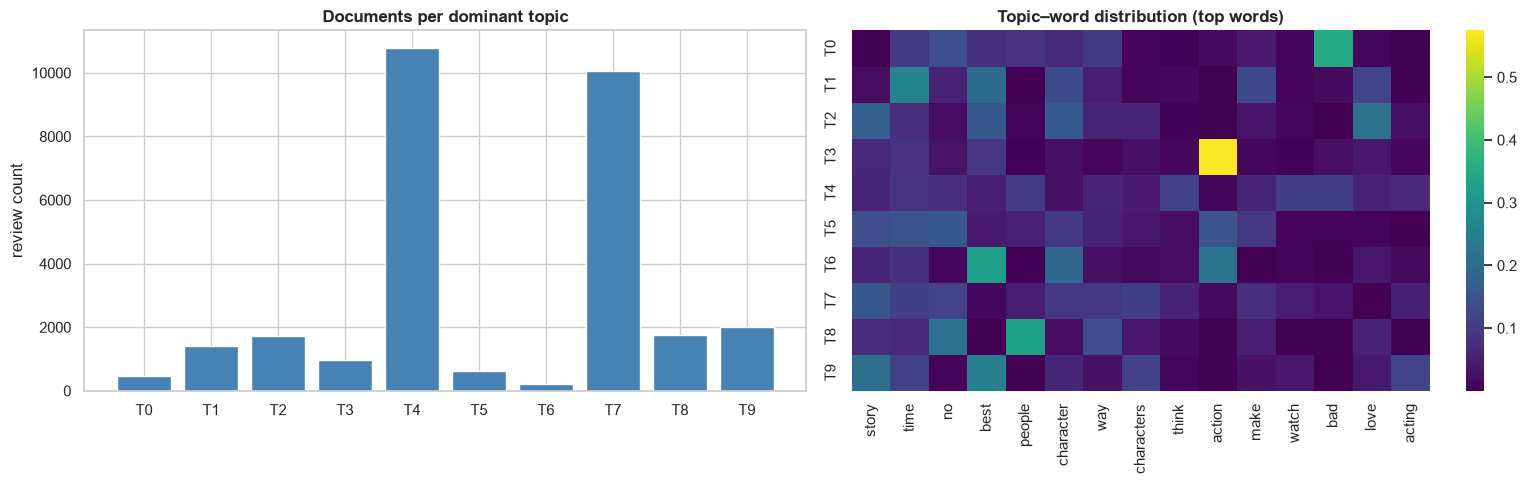

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) how many documents each topic dominates
dominant = lda_topics.argmax(axis=1)
topic_sizes = pd.Series(dominant).value_counts().sort_index()
axes[0].bar([f"T{i}" for i in topic_sizes.index], topic_sizes.values, color="steelblue")
axes[0].set_title("Documents per dominant topic", fontweight="bold")
axes[0].set_ylabel("review count")

# (b) topic–word strength heatmap for the top words overall
top_overall = lda.components_.sum(axis=0).argsort()[:-16:-1]   # 15 strongest words
heat = lda.components_[:, top_overall]
heat = heat / heat.sum(axis=1, keepdims=True)                  # normalize per topic
sns.heatmap(heat, xticklabels=[vocab[i] for i in top_overall],
            yticklabels=[f"T{i}" for i in range(N_TOPICS)],
            cmap="viridis", ax=axes[1])
axes[1].set_title("Topic–word distribution (top words)", fontweight="bold")

plt.tight_layout()
plt.show()

### Summary of Topic Modeling Results

- Topic sizes are very uneven: Topics 4 and 7 together account for about
  two-thirds of the 30,000 sampled reviews, while several other topics
  (0, 3, 5, 6) each cover under 1,000 reviews.
- A few topics are dominated by a single strong word (e.g. Topic 3 by
  "action", Topic 0 by "bad") rather than a balanced mix of terms.
- Combined with LDA's earlier tendency to repeat generic words ("best",
  "story", "character") across multiple topics, this suggests 10 topics
  is likely more than this corpus naturally supports at this sample size
  — a smaller number (6-7) would probably give more even, more distinct
  groupings.
- NMF still separated topics more cleanly than LDA overall (Bond, Batman,
  horror, and comedy all came out as sharp, distinct topics), so the
  overlap/imbalance issue shows up more in LDA specifically.

**Overall:** topic modeling successfully surfaced real, interpretable
themes in the reviews, but the chosen topic count (10) was probably set
a bit too high for this dataset.

### 4.2 Supervised Learning

In [21]:
#========================================
#General Evaluation Function
#========================================

results = {}   # each model appends here for the final comparison

def evaluate(name, model, X_te, y_te):
     """Train already done; this scores on the untouched test set and stores key metrics."""
     y_pred = model.predict(X_te)
     rep = classification_report(y_te, y_pred, output_dict=True)
     results[name] = {
         "accuracy":      rep["accuracy"],
         "neg_recall":    rep["negative"]["recall"],
         "neg_precision": rep["negative"]["precision"],
         "neg_f1":        rep["negative"]["f1-score"],
         "macro_f1":      rep["macro avg"]["f1-score"],
         "balanced_acc":  balanced_accuracy_score(y_te, y_pred),
     }
     print(f"========================== {name} =====================================")
     print(classification_report(y_te, y_pred))
     print("Confusion matrix [rows=true, cols=pred], classes:", model.classes_)
     print(confusion_matrix(y_te, y_pred))
     print()

## Machine Learning Models

### 1st MODEL: LOGISTIC REGRESSION

In [22]:
logreg = LogisticRegression(class_weight="balanced", max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
evaluate("LogisticRegression", logreg, X_test_tfidf, y_test)

========================== LogisticRegression =====================================
              precision    recall  f1-score   support

    negative       0.73      0.89      0.80      7974
    positive       0.97      0.92      0.95     34198

    accuracy                           0.92     42172
   macro avg       0.85      0.91      0.88     42172
weighted avg       0.93      0.92      0.92     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 7073   901]
 [ 2576 31622]]



### 2nd MODEL: LINEAR SUPPORT VECTOR CLASSIFIER

In [23]:
linsvm = LinearSVC(class_weight="balanced", max_iter=2000, dual="auto")
linsvm.fit(X_train_tfidf, y_train)
evaluate("LinearSVM", linsvm, X_test_tfidf, y_test)

========================== LinearSVM =====================================
              precision    recall  f1-score   support

    negative       0.72      0.84      0.78      7974
    positive       0.96      0.92      0.94     34198

    accuracy                           0.91     42172
   macro avg       0.84      0.88      0.86     42172
weighted avg       0.92      0.91      0.91     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 6698  1276]
 [ 2570 31628]]



### 3rd MODEL:  RANDOM FOREST CLASSIFIER

In [24]:
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
rf.fit(X_train_tfidf, y_train)
evaluate("RandomForest", rf, X_test_tfidf, y_test)

========================== RandomForest =====================================
              precision    recall  f1-score   support

    negative       0.80      0.68      0.74      7974
    positive       0.93      0.96      0.94     34198

    accuracy                           0.91     42172
   macro avg       0.87      0.82      0.84     42172
weighted avg       0.90      0.91      0.91     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 5446  2528]
 [ 1340 32858]]



### Compare the 3 Machine Learning Models
Winner: Logistic Regression

Across the three sparse-feature models, Logistic Regression leads on macro-F1 and
balanced accuracy while keeping the strongest negative-class recall.

In [63]:
comparison = pd.DataFrame(results).T
print(comparison.round(3).sort_values("macro_f1", ascending=False))

                    accuracy  neg_recall  neg_precision  neg_f1  macro_f1  \
LogisticRegression     0.918       0.887          0.733   0.803     0.875   
LinearSVM              0.909       0.840          0.723   0.777     0.860   
RandomForest           0.908       0.683          0.803   0.738     0.841   
MLP_MiniLM             0.885       0.585          0.753   0.658     0.795   

                    balanced_acc  
LogisticRegression         0.906  
LinearSVM                  0.882  
RandomForest               0.822  
MLP_MiniLM                 0.770  


### Embedding Comparison Result Analysis
Same classifier (LogReg) and the same 8k rows for all three representations, so any
difference is attributable to the **embedding**, not the model.
macro-F1 is reported , alongside dimensionality and encode time (the advantages/disadvantages axis)
A general-purpose transformer embedding scored lowest (0.74), below both TF-IDF (0.86) and averaged Word2Vec (0.82). MiniLM optimizes for semantic similarity, not sentiment polarity — sentences with opposite sentiment but similar meaning are placed close together, which a linear classifier cannot separate. This shows that embedding sophistication does not guarantee task performance: the representation must match what the task actually discriminates on.

In [26]:
# smaller sample
sample, _ = train_test_split(df, train_size=8000, random_state=42, stratify=df["label"])
train_part, test_part = train_test_split(
    sample, test_size=0.2, random_state=42, stratify=sample["label"]
)
y_train_e, y_test_e = train_part["label"], test_part["label"]

embedding_results = {}   # collect each method's score here

def evaluate_embedding(name, X_train_vec, X_test_vec, seconds):
    """Train LogReg on the given vectors and record macro-F1, size, and speed."""
    model = LogisticRegression(max_iter=1000, class_weight="balanced")
    model.fit(X_train_vec, y_train_e)
    macro_f1 = f1_score(y_test_e, model.predict(X_test_vec), average="macro")

    embedding_results[name] = {
        "macro_f1":   round(macro_f1, 4),
        "dimensions": X_train_vec.shape[1],   # how many numbers per document
        "encode_sec": round(seconds, 1),      # how long the vectors took to build
    }
    print(f"{name:14} | macro-F1 = {macro_f1:.4f} | dims = {X_train_vec.shape[1]:>5} | {seconds:.1f}s")

# --- A. TF-IDF : sparse, based on exact words -------------------------
start = time.time()
tfidf = TfidfVectorizer(max_features=40000, ngram_range=(1, 2), min_df=5, sublinear_tf=True)
X_train_tfidf_e = tfidf.fit_transform(train_part["tokens"])   # fit on train only
X_test_tfidf_e  = tfidf.transform(test_part["tokens"])
evaluate_embedding("TF-IDF", X_train_tfidf_e, X_test_tfidf_e, time.time() - start)

# --- B. Word2Vec (averaged) : dense, based on word meaning ------------
# Each word has a vector; we average them to get one vector per review.
# averaging loses word order, so "not good" ≈ "good".
def document_vector(text):
    words = advanced_normalize_text(text, mode="none").split()
    word_vecs = [w2v.wv[w] for w in words if w in w2v.wv]
    if len(word_vecs) == 0:
        return np.zeros(w2v.vector_size)      # review had no known words
    return np.mean(word_vecs, axis=0)

start = time.time()
X_train_w2v = np.vstack([document_vector(t) for t in train_part["text_clean"]])
X_test_w2v  = np.vstack([document_vector(t) for t in test_part["text_clean"]])
evaluate_embedding("Word2Vec-avg", X_train_w2v, X_test_w2v, time.time() - start)

# --- C. MiniLM : dense, understands whole sentences -------------------
start = time.time()
minilm = SentenceTransformer("all-MiniLM-L6-v2")
X_train_minilm = minilm.encode(train_part["text_clean"].tolist(),
                               batch_size=64, show_progress_bar=True)
X_test_minilm  = minilm.encode(test_part["text_clean"].tolist(),
                               batch_size=64, show_progress_bar=True)
evaluate_embedding("MiniLM", X_train_minilm, X_test_minilm, time.time() - start)
# --- Results table ---------------------------------------------------
print("\nComparison of embedding techniques:")
print(pd.DataFrame(embedding_results).T)

TF-IDF         | macro-F1 = 0.8553 | dims = 26640 | 3.4s
Word2Vec-avg   | macro-F1 = 0.8313 | dims =   100 | 4.7s


Batches: 100%|██████████| 25/25 [00:41<00:00,  1.68s/it]

MiniLM         | macro-F1 = 0.7357 | dims =   384 | 225.4s

Comparison of embedding techniques:
              macro_f1  dimensions  encode_sec
TF-IDF          0.8553     26640.0         3.4
Word2Vec-avg    0.8313       100.0         4.7
MiniLM          0.7357       384.0       225.4


### Most Distinctive Words per Class

Raw frequency is uninformative — the commonest words are nearly identical in both
classes. Instead each word is scored by a **ratio**: how many times more often it
appears in one class than the other (+1 smoothing, minimum 500 occurrences).

**The words are stems** — `superbl`, `flawlessli`, `unfunni`, `abysm`, `wast` are
*superbly*, *flawlessly*, *unfunny*, *abysmal*, *waste*. Visual confirmation that
the stemming stage works, and a reminder of why Word2Qec used unstemmed text.

**The two x-axes differ in scale** (positive to 43, negative to 3.5). This reflects
the 4.3:1 class imbalance, not stronger positive sentiment: with four times more
positive text available, a positive-only word can reach a far higher ratio than a
negative-only one. Rank words within each panel, not across them.

**Proper nouns appear alongside sentiment words** — `miyazaki`, `kurosawa`,
`corleon`, `mcu`, `ultron` on the positive side; `boll` (Uwe Boll) on the negative.
This is real signal but a limitation: names encode *identity*, not *opinion*, so
they won't generalize to unseen films the way `flawless` or `stinker` will.

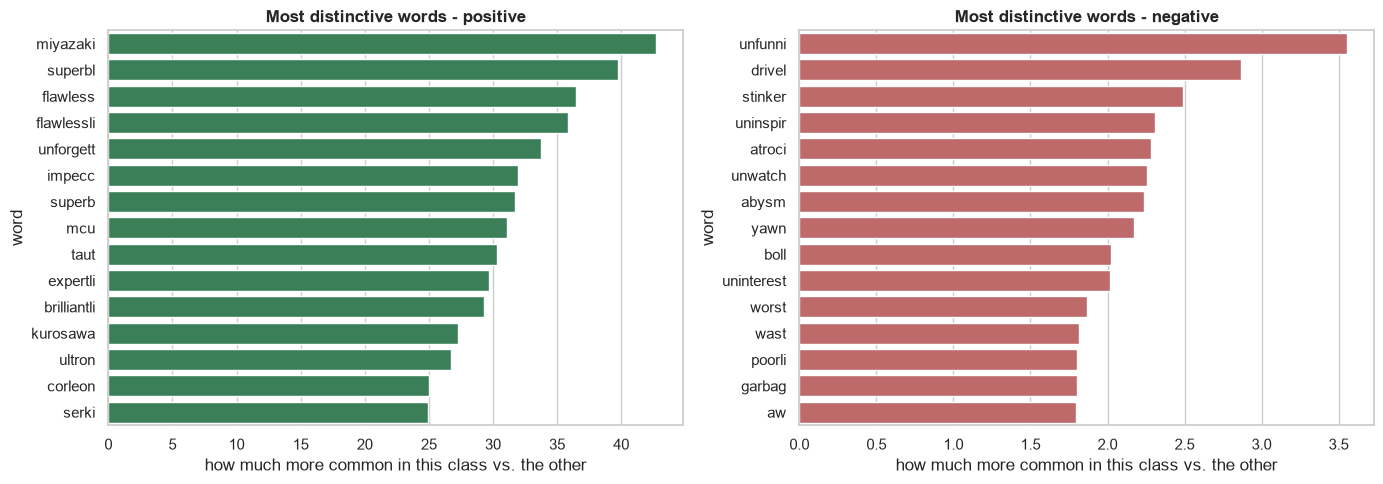

In [27]:
# Top-15 words that are MOST DISTINCTIVE per class, not just most frequent.
# Raw frequency surfaces generic words common to both classes (movie, film,
# not, good...) -- a ratio comparing how much more often a word appears in
# one class vs. the other actually shows what separates positive from
# negative reviews.

pos_counts = Counter(" ".join(df[df["label"] == "positive"]["tokens"]).split())
neg_counts = Counter(" ".join(df[df["label"] == "negative"]["tokens"]).split())

# only consider words common enough to be meaningful, not rare one-offs
vocab = {w for w in pos_counts if pos_counts[w] + neg_counts.get(w, 0) > 500}

# +1 smoothing avoids dividing by zero for words absent from one class
pos_ratio = {w: (pos_counts[w] + 1) / (neg_counts.get(w, 0) + 1) for w in vocab}
neg_ratio = {w: (neg_counts[w] + 1) / (pos_counts.get(w, 0) + 1) for w in vocab}

top_pos = pd.DataFrame(
    sorted(pos_ratio.items(), key=lambda x: x[1], reverse=True)[:15],
    columns=["word", "ratio"]
)
top_neg = pd.DataFrame(
    sorted(neg_ratio.items(), key=lambda x: x[1], reverse=True)[:15],
    columns=["word", "ratio"]
)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, data, ttl, col in [(ax[0], top_pos, "Most distinctive words - positive", "seagreen"),
                          (ax[1], top_neg, "Most distinctive words - negative", "indianred")]:
    sns.barplot(data=data, y="word", x="ratio", ax=a, color=col)
    a.set_title(ttl, fontweight="bold")
    a.set_xlabel("how much more common in this class vs. the other")

plt.tight_layout()
plt.show()

### Deep Learning Model - Multi-Layer Perceptron (MLP)

In [29]:
# ============================================================
# MiniLM sentence embeddings for the DL model.
# Encode text_clean (real English), aligned to the CURRENT split.
# Cache is reused ONLY if its row count matches -- guards against stale files.
# ============================================================

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    emb_dir = "/content/drive/MyDrive/cinesquad_cache/embeddings"
else:
    # kernel cwd is notebooks/, so this lands at <project_root>/embeddings
    emb_dir = os.path.join(os.getcwd(), os.pardir, "embeddings")

os.makedirs(emb_dir, exist_ok=True)
print("Cache dir:", os.path.abspath(emb_dir))

train_path = os.path.join(emb_dir, "X_train_emb.npy")
test_path  = os.path.join(emb_dir, "X_test_emb.npy")

encoder = SentenceTransformer("all-MiniLM-L6-v2")

rebuild = True
if os.path.exists(train_path) and os.path.exists(test_path):
    ctr, cte = np.load(train_path), np.load(test_path)
    # row-count check catches a cache built before the cleaning step changed len(df)
    if ctr.shape[0] == len(y_train) and cte.shape[0] == len(y_test):
        X_train_emb, X_test_emb, rebuild = ctr, cte, False
        print("Loaded cached embeddings:", X_train_emb.shape, X_test_emb.shape)
    else:
        print(f"Cache stale ({ctr.shape[0]} vs {len(y_train)}) -> re-embedding")

if rebuild:
    X_train_emb = encoder.encode(df.loc[X_train.index, "text_clean"].tolist(),
                                 batch_size=64, show_progress_bar=True)
    X_test_emb  = encoder.encode(df.loc[X_test.index, "text_clean"].tolist(),
                                 batch_size=64, show_progress_bar=True)
    np.save(train_path, X_train_emb); np.save(test_path, X_test_emb)
    print("Encoded & cached:", X_train_emb.shape, X_test_emb.shape)

assert X_train_emb.shape[0] == len(y_train)
assert X_test_emb.shape[0]  == len(y_test)

# MLP head on the frozen MiniLM embeddings.
mlp = MLPClassifier(hidden_layer_sizes=(128,), activation="relu",
                    max_iter=300, early_stopping=True, random_state=42)
mlp.fit(X_train_emb, y_train)            # same labels/rows as the other models
evaluate("MLP_MiniLM", mlp, X_test_emb, y_test)


Cache dir: D:\Downloads\nlp-finalproject-cinesquad-main\embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4194.02it/s]


Loaded cached embeddings: (168684, 384) (42172, 384)


### Model Comparison

In [30]:
comparison = pd.DataFrame(results).T
print(comparison.round(3).sort_values("macro_f1", ascending=False))

========================== MLP_MiniLM =====================================
              precision    recall  f1-score   support

    negative       0.75      0.59      0.66      7974
    positive       0.91      0.96      0.93     34198

    accuracy                           0.89     42172
   macro avg       0.83      0.77      0.79     42172
weighted avg       0.88      0.89      0.88     42172

Confusion matrix [rows=true, cols=pred], classes: ['negative' 'positive']
[[ 4665  3309]
 [ 1533 32665]]

                    accuracy  neg_recall  neg_precision  neg_f1  macro_f1  \
LogisticRegression     0.918       0.887          0.733   0.803     0.875   
LinearSVM              0.909       0.840          0.723   0.777     0.860   
RandomForest           0.908       0.683          0.803   0.738     0.841   
MLP_MiniLM             0.885       0.585          0.753   0.658     0.795   

                    balanced_acc  
LogisticRegression         0.906  
LinearSVM                  0.882  


## Model Comparison Summary

All four models were evaluated on an imbalanced test set of 42,172 reviews (34,198 positive, 7,974 negative — a **4.29 : 1 imbalance**). 

#### **1. The Metric Trap: Why Accuracy Misleads**
* Standard accuracy is a deceptive metric for this dataset. A baseline model that blindly predicts "positive" for every single review would achieve **81.1% accuracy** without learning any patterns.
* While all models beat this baseline, their overall accuracies are clustered tightly together (0.885 to 0.918). 
* The true differences appear in **macro F1** and **balanced accuracy**, which average performance across both classes and expose major gaps in negative-class recall (ranging from 0.585 to 0.887).

#### **2. Performance Leaderboard**
* **Logistic Regression (Winner):** Outperformed all competitors, leading with the highest **macro F1 (0.875)** and **balanced accuracy (0.906)**. Using `class_weight="balanced"` pushed its decision boundary toward the minority class, achieving the top negative recall (**0.887**) at the cost of a few more false alarms.
* **LinearSVM:** Finished second, confirming that linear boundaries excel on high-dimensional, sparse text representations.
* **Random Forest:** Took a conservative approach. It yielded the highest negative precision (**0.803**) — meaning its negative predictions are highly trustworthy — but it only caught **68.3%** of the actual negative reviews.
* **MLP on MiniLM (Last Place):** Suffered a severe breakdown on the minority class, misclassifying **41.5% of negative reviews as positive**. Its deceptively high accuracy (0.885) completely hid this flaw.

---

#### **3. Key Architectural Insights**

* **Why the Deep Model Failed (MiniLM + MLP):**
  1. **Semantic Compression vs. Lexical Signal:** Sentiment is heavily word-dependent. TF-IDF keeps words like *"brilliant"* and *"dreadful"* entirely distinct. Compressing text into MiniLM's 384 dense dimensions optimizes for *topical similarity* instead. Because those two words are contextually similar, they end up as near-neighbors, erasing the polarity signal.
  2. **The Frozen Encoder Bottleneck:** Because the MiniLM encoder was kept frozen, the MLP classification head could only work with general-purpose embeddings. Without full transformer fine-tuning to reshape the embedding space specifically around sentiment polarity, neural approaches struggle to beat strong, simple linear baselines on medium-sized text corpora.

## Apply XAI (Explainable AI) - Global Coefficient Inspection

The best model (**Logistic Regression**) is explained on a **global** basis by
inspecting its' learned coefficients. The brief allows XAI "on either a local or
global basis", and for a linear model the coefficients *are* the decision rule
(prediction = sum of coefficient x TF-IDF value), so this is exact rather than an
approximation. We look in particular for sign inversions between a word and its
negated bigram, which validate the negation handling and the use of bigrams.

In [31]:
# GLOBAL explainability via LogReg coefficients.
# For a linear model prediction = sum(coef * tfidf), so the coefficients ARE the
# reasoning (exact, not an approximation like LIME). The brief allows XAI on a
# "local OR global basis", so coefficient inspection satisfies it.
names  = vectorizer.get_feature_names_out()
coef_df = pd.DataFrame({"term": names, "weight": logreg.coef_[0]})

print("Top POSITIVE terms:")
print(coef_df.sort_values("weight", ascending=False).head(12).to_string(index=False))
print("\nTop NEGATIVE terms:")
print(coef_df.sort_values("weight").head(12).to_string(index=False))

# Look for the sign inversion that validates negation-handling + bigrams:
for t in ["disappoint", "not disappoint", "not recommend", "not worth"]:
    row = coef_df[coef_df["term"] == t]
    if len(row):
        print(f"  {t:16} {row['weight'].iloc[0]:+.2f}")

Top POSITIVE terms:
          term   weight
         great 9.916825
         excel 8.819095
not disappoint 8.620371
          best 8.290096
       perfect 7.939938
     brilliant 7.228408
        awesom 6.991632
          amaz 6.511616
        superb 6.430213
         solid 5.815486
         enjoy 5.783074
       definit 5.720607

Top NEGATIVE terms:
         term     weight
         bore -11.376738
        worst -10.238390
   disappoint  -9.838906
         wast  -9.802483
          bad  -8.655687
           aw  -8.520244
    not worth  -8.274738
not recommend  -8.157135
         fail  -7.579056
         poor  -7.190862
         dull  -7.081739
      terribl  -7.046137
  disappoint       -9.84
  not disappoint   +8.62
  not recommend    -8.16
  not worth        -8.27


## 4.2 Retrieval-Augmented Generation (RAG) for Conversational AI

In [32]:
# Opens an input box. Paste your key there - it is NOT saved in the notebook cells/output.
os.environ["GEMINI_API_KEY"] = getpass.getpass("Paste your Gemini API key: ")

# Verify the kernel now has it (prints True, not the key itself)
print("Key loaded:", bool(os.environ.get("GEMINI_API_KEY")))

Paste your Gemini API key:  ········


Key loaded: True


In [33]:
!pip install -q google-genai
from google import genai

# Client() picks up GEMINI_API_KEY from the environment — no need to pass it
client = genai.Client()

print(client.models.generate_content(
    model="gemini-2.5-flash", contents="Reply with the single word OK."
).text)

OK


In [35]:
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files
    print("Select labeled_reviews.csv:")
    csv_name = next(iter(files.upload()))
    print("Select metadata.json:")
    json_name = next(iter(files.upload()))
else:
    # kernel cwd is notebooks/, so ../ reaches the project root
    base = os.path.join(os.getcwd(), os.pardir, "movie_dataset_public_final")
    csv_name  = os.path.join(base, "processed", "labeled_reviews.csv")
    json_name = os.path.join(base, "raw", "metadata.json")

for p in (csv_name, json_name):
    print(os.path.abspath(p), "| exists:", os.path.exists(p))

# 1. Labeled reviews
reviews = pd.read_csv(csv_name)
print("reviews:", reviews.shape, reviews.columns.tolist())

# 2. Movie metadata (lines=True handles one-JSON-object-per-line format)
meta = pd.read_json(json_name, lines=True)
print("metadata:", meta.shape, meta.columns.tolist())

# 3. Join reviews to their movie metadata
merged = pd.merge(
    reviews,
    meta[["item_id", "title", "directedBy", "starring"]],
    on="item_id",
    how="inner",     # keep only rows present in BOTH
)
print("merged rows:", merged.shape[0])
print("distinct movies:", merged["item_id"].nunique())

D:\Downloads\nlp-finalproject-cinesquad-main\movie_dataset_public_final\processed\labeled_reviews.csv | exists: True
D:\Downloads\nlp-finalproject-cinesquad-main\movie_dataset_public_final\raw\metadata.json | exists: True
reviews: (210997, 4) ['item_id', 'text', 'score', 'label']
metadata: (84661, 7) ['title', 'directedBy', 'starring', 'dateAdded', 'avgRating', 'imdbId', 'item_id']
merged rows: 210919
distinct movies: 26491


The merged table has one row per review, and popular movies have hundreds of
reviews. MiniLM (the embedding model) reads at most 256 tokens — roughly
1,000–1,500 characters — so anything past that point contributes nothing to the
vector and is invisible to retrieval. We therefore cap each document at ~1,500
characters, which works out to about 4 reviews of a few hundred characters each;
a 5th would mostly fall past the cutoff.

`groupby("item_id").head(4)` keeps the first 4 rows of each movie's group, where
"first" means file order — not random. Shuffling the whole table once beforehand
makes "first 4" equivalent to "4 random reviews," so each document is an
unbiased sample of that movie's opinions.

In [36]:
# ============================================================
# Sample up to 4 reviews per movie
# Shuffle first so "the first 4 per group" is really a random 4,
# not just whatever order the file happened to be in.
# ============================================================
sampled = (
    merged
    .sample(frac=1, random_state=42)
    .groupby("item_id")
    .head(4)
)

print("kept reviews:", sampled.shape[0])
print(sampled.groupby("item_id").size().value_counts())

kept reviews: 65377
4    9796
1    9692
2    4508
3    2495
Name: count, dtype: int64


#### The finding: the Corpus is deeply uneven
9,692 movies — 37% of the corpus — are represented by a single review. Only ~9,796 (37%) hit the 4-review cap. The rest sit in between.

### Collapse to one row per movie

In [37]:
docs = sampled.groupby("item_id").agg(
    title=("title", "first"),
    directedBy=("directedBy", "first"),
    starring=("starring", "first"),
    reviews=("text", " | ".join),
).reset_index()

docs[["directedBy", "starring"]] = docs[["directedBy", "starring"]].fillna("")

print(docs.shape)
docs.head()

(26491, 5)


,item_id,title,directedBy,starring,reviews
0,1,Toy Story (1995),John Lasseter,"Tim Allen, Tom Hanks, Don Rickles, Jim Varney,...",Imaginative Breakthrough.; Toy Story (1995): D...
1,2,Jumanji (1995),Joe Johnston,"Jonathan Hyde, Bradley Pierce, Robin Williams,...","Clever, deep, accidental?; I think it helps to..."
2,3,Grumpier Old Men (1995),Howard Deutch,"Jack Lemmon, Walter Matthau, Ann-Margret , Sop...",Funnier old B***ards; This really is a pretty ...
3,4,Waiting to Exhale (1995),Forest Whitaker,"Angela Bassett, Loretta Devine, Whitney Housto...",WHINE! WHINE! WHINE!; With all the hype surrou...
4,5,Father of the Bride Part II (1995),Charles Shyer,"Steve Martin, Martin Short, Diane Keaton, Kimb...","not bad for a sequel; as sequels go,this is fi..."


## TMDB Data Preparation

This cell loads the TMDB dataset and gets it ready to be joined with our own
corpus, using movie title + year as the matching key (TMDB has no shared ID
with our MovieLens-based data).

**Steps:**

1. **Load the file** — `tmdb_5000_movies.csv`, containing ~4,800 movies with
   fields like `title`, `overview` (real plot summaries), `genres`,
   `keywords`, `release_date`, and `vote_count`.

2. **Parse genres/keywords** — TMDB stores these as text that *looks* like a
   list of dictionaries (e.g. `'[{"name": "Action"}]'`), not an actual Python
   list. `parse_names()` uses `ast.literal_eval` to safely convert that text
   into a real list, then pulls out just the name fields. Keywords are capped
   at 8 per movie since some films have dozens.

3. **Extract the year** — `release_date` is a full date string
   ("1994-09-10"); we only need the year (1994) to match against our own
   corpus, which stores year the same way in its titles.

4. **Normalize titles** — `norm_title()` lowercases everything, strips
   punctuation, and removes a leading "The" or trailing ", The" so that
   "The Matrix" and "Matrix, The" become the same string. Without this,
   formatting differences between the two datasets would prevent matches.

5. **Build the join key** — combines the normalized title and year into one
   string (e.g. `"matrix|1999"`). This is the key used later to merge TMDB's
   plot/genre data into our corpus. Rows missing a year get no key, since
   title alone risks matching the wrong movie (e.g. a remake from a
   different year).

6. **Slim down and report** — keep only the columns we actually need, drop
   rows with no usable key, and print how many TMDB movies are ready to be
   matched.

**Limitation to note:** TMDB only covers ~4,800 movies, a small fraction of
our ~26491-movie corpus, and title-based matching (rather than a shared ID)
means some genuine matches will still be missed due to formatting quirks
not caught by normalization.

In [40]:
# ============================================================
# Load TMDB and build a matching key (normalized title + year)
# TMDB has no shared ID with our data, so title+year is the best
# available join key.
# ============================================================
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import files
    tmdb_name = next(iter(files.upload()))   # survives "(1)" renaming
else:
    # adjust the subfolder if you keep it elsewhere
    tmdb_name = os.path.join(os.getcwd(), os.pardir,
                             "tmdb_5000_movies.csv")

print(os.path.abspath(tmdb_name), "| exists:", os.path.exists(tmdb_name))
tmdb = pd.read_csv(tmdb_name)
def parse_names(json_str, limit=None):
    """TMDB stores genres/keywords as a JSON-like string, e.g.
    '[{"name": "Action"}, ...]'. Extract just the names."""
    try:
        items = ast.literal_eval(json_str) if isinstance(json_str, str) else []
        names = [d["name"] for d in items]
        return names[:limit] if limit else names
    except (ValueError, SyntaxError, TypeError):
        return []

def norm_title(t):
    """Lowercase, strip punctuation, drop a leading/trailing 'the'."""
    t = str(t).lower().strip()
    t = re.sub(r"^the\s+|,\s*the$", "", t)
    t = re.sub(r"[^a-z0-9 ]", "", t)
    return t.strip()

tmdb["genre_names"]   = tmdb["genres"].apply(parse_names)
tmdb["keyword_names"] = tmdb["keywords"].apply(lambda s: parse_names(s, limit=8))
tmdb["year"] = pd.to_datetime(tmdb["release_date"], errors="coerce").dt.year

# Int64 keeps year as a nullable integer, so no ":.0f" float formatting needed
tmdb["year"] = tmdb["year"].astype("Int64")
tmdb["join_key"] = tmdb.apply(
    lambda r: f"{norm_title(r['title'])}|{r['year']}" if pd.notna(r["year"]) else None,
    axis=1
)

tmdb_slim = (
    tmdb[["join_key", "overview", "genre_names", "keyword_names", "vote_count"]]
    .dropna(subset=["join_key"])
    .rename(columns={"overview": "plot_overview"})
)                                   # <-- the missing paren

# Duplicate join_keys would multiply rows in the left join later.
# Keep the best-known version of each title-year.
dups = tmdb_slim["join_key"].duplicated().sum()
tmdb_slim = (
    tmdb_slim.sort_values("vote_count", ascending=False)
             .drop_duplicates(subset="join_key", keep="first")
)

print("TMDB movies with a usable join key:", len(tmdb_slim))
print("duplicate join_keys collapsed:", dups)

D:\Downloads\nlp-finalproject-cinesquad-main\tmdb_5000_movies.csv | exists: True
TMDB movies with a usable join key: 4802
duplicate join_keys collapsed: 0


## Building the Corpus-Side Join Key

Before we can merge TMDB's plot data into our own corpus, we need to build
a matching key on our side using the same format as the TMDB key
("normalized title | year").

**Steps:**

1. **Extract the year** — our corpus titles look like `"Matrix, The (1999)"`.
   A regex checks whether the title ends with a 4-digit year in parentheses.
   If it doesn't, we can't build a key for that movie, so it's marked as
   unmatched (`None`) and will simply not find a TMDB match later.

2. **Strip the year from the title** — once the year is captured, it's
   removed from the string, leaving just the bare title (`"Matrix, The"`).

3. **Normalize and combine** — the same `norm_title()` function used for
   TMDB is applied here too, so formatting differences (e.g. "Matrix, The"
   vs. "The Matrix") don't prevent a match. The final key is
   `"normalized_title|year"`, identical in format to TMDB's key.

4. **Check match rate** — using `.isin()`, we check how many of our
   corpus's keys actually exist in TMDB's set of keys. This tells us what
   percentage of our ~26491-movie corpus can realistically be enriched
   with real plot summaries from TMDB, versus how many will fall back to
   review-only text.

**Limitation to note:** any corpus title that doesn't end in a clean
"(YYYY)" pattern will fail to produce a join key at all, even if TMDB
genuinely has that movie — this is a formatting limitation of our matching
approach, not necessarily a true absence of the movie from TMDB. We checked
how many titles fall into this case to make sure our reported match rate is
trustworthy.

In [41]:
# ============================================================
# Build our own join key, then merge TMDB data into docs
# ============================================================
# corpus titles look like "Matrix, The (1999)" -- split into title + year
def corpus_join_key(title):
    """Our titles look like 'Matrix, The (1999)' -- pull out the year
    and normalize the rest the same way as the TMDB side."""
    m = re.search(r"\((\d{4})\)\s*$", str(title))
    if not m:
        return None
    year = m.group(1)
    base = re.sub(r"\s*\(\d{4}\)\s*$", "", str(title))
    return f"{norm_title(base)}|{year}"

docs["join_key"] = docs["title"].apply(corpus_join_key)

matched = docs["join_key"].isin(set(tmdb_slim["join_key"]))
print(f"corpus movies: {len(docs)}")
print(f"matched to TMDB: {matched.sum()} ({matched.mean()*100:.1f}%)")


corpus movies: 26491
matched to TMDB: 3859 (14.6%)


In [42]:
enriched = docs.merge(tmdb_slim, on="join_key", how="left")

print("docs rows:", len(docs), "-> enriched rows:", len(enriched))   # must be equal
print("matched:", enriched["plot_overview"].notna().sum())
print("coverage: {:.1%}".format(enriched["plot_overview"].notna().mean()))

# Sanity check the film we know should match
print(enriched.loc[enriched["join_key"] == "titanic|1997",
                   ["title", "plot_overview"]].to_dict("records"))

docs rows: 26491 -> enriched rows: 26491
matched: 3859
coverage: 14.6%
[{'title': 'Titanic (1997)', 'plot_overview': '84 years later, a 101-year-old woman named Rose DeWitt Bukater tells the story to her granddaughter Lizzy Calvert, Brock Lovett, Lewis Bodine, Bobby Buell and Anatoly Mikailavich on the Keldysh about her life set in April 10th 1912, on a ship called Titanic when young Rose boards the departing ship with the upper-class passengers and her mother, Ruth DeWitt Bukater, and her fiancé, Caledon Hockley. Meanwhile, a drifter and artist named Jack Dawson and his best friend Fabrizio De Rossi win third-class tickets to the ship in a game. And she explains the whole story from departure until the death of Titanic on its first and last voyage April 15th, 1912 at 2:20 in the morning.'}]


In [43]:
# ============================================================
# Build the final overview text (what the app embeds and displays).
# Plot precedes reviews so the embedding anchors on what the movie
# is ABOUT; reviews come last, since they add opinion, not content.
# Falls back to reviews-only when there's no TMDB match.
# ============================================================
def build_overview(row):
    parts = [f"Title: {row['title']}"]

    # NaN for unmatched rows is a float, so isinstance() guards are required —
    # a bare truthiness check would raise TypeError inside join()
    if isinstance(row.get("genre_names"), list) and row["genre_names"]:
        parts.append("Genres: " + ", ".join(row["genre_names"]))
    if isinstance(row.get("keyword_names"), list) and row["keyword_names"]:
        parts.append("Themes: " + ", ".join(row["keyword_names"]))
    if isinstance(row.get("plot_overview"), str) and row["plot_overview"].strip():
        parts.append("Plot: " + row["plot_overview"].strip())
    if isinstance(row.get("directedBy"), str) and row["directedBy"].strip():
        parts.append(f"Directed by {row['directedBy']}")
    if isinstance(row.get("starring"), str) and row["starring"].strip():
        parts.append(f"Starring {row['starring']}")

    parts.append("Reviews: " + str(row["reviews"]))
    return " | ".join(parts)

enriched["overview"] = enriched.apply(build_overview, axis=1)

# Coverage check: should be 3,859 if the guards are working
print("docs with a Plot section:", enriched["overview"].str.contains("Plot:").sum())

# Titanic should now carry its synopsis before the reviews
print(enriched.loc[enriched["title"] == "Titanic (1997)", "overview"].iloc[0][:400])

docs with a Plot section: 4016
Title: Titanic (1997) | Genres: Drama, Romance, Thriller | Themes: shipwreck, iceberg, ship, panic, titanic, ocean liner, epic, rich woman - poor man | Plot: 84 years later, a 101-year-old woman named Rose DeWitt Bukater tells the story to her granddaughter Lizzy Calvert, Brock Lovett, Lewis Bodine, Bobby Buell and Anatoly Mikailavich on the Keldysh about her life set in April 10th 1912, on a ship


### Build Overview column

Why keep the ratings in for RAG? Because Gemini can use them. When someone asks "Is Inception worth watching?", a review saying "8/10, brilliant" is direct, quotable evidence. Gemini reads "8/10" and cites it in the answer. Stripping it would throw away exactly the signal that helps answer worth-watching questions.

## Separating Retrieval Text from Display Text

Initial testing showed that pure semantic retrieval performed poorly on
plot-style questions (18% hit-rate@3), even after enriching the corpus
with TMDB plot summaries. Investigating the misses (e.g. "a shark
terrorizes a beach town" retrieving unrelated shark-themed movies instead
of Jaws) suggested a specific cause: our `overview` field blends plot text
with review text, and the embedding model represents the *whole* string
as one vector — so lengthy, opinion-heavy review text can dilute the
plot signal, even when a correct plot summary is present in the same
document.

**Fix:** we build a separate `retrieval_text` column used only for
computing embeddings — plot summary only, when available, falling back
to the full `overview` for movies with no TMDB match. The original
`overview` column (plot + director + cast + reviews) is left unchanged
and still used for what the user sees and what the generator reads —
only the *retrieval* step now searches against plot-focused text instead
of the full blended document.

This is a case of separating the "retrieval representation" (what we
search against) from the "display representation" (what we show/generate
from) — a known technique for RAG systems where a document is richer than
what's ideal for pure similarity matching.

In [44]:
# ============================================================
# Build a SEPARATE text for embedding (what we search on)
# Reviews add noise to semantic search on plot-style questions, so
# we embed plot-only text when available, falling back to the full
# overview otherwise. The display text (overview) is untouched.
# ============================================================
def retrieval_text(row):
    has_plot = isinstance(row.get("plot_overview"), str) and row["plot_overview"].strip()
    if not has_plot:
        return row["overview"]        # unmatched: keep reviews, they're all we have

    parts = [row["title"]]
    if isinstance(row.get("genre_names"), list) and row["genre_names"]:
        parts.append("Genres: " + ", ".join(row["genre_names"]))
    if isinstance(row.get("keyword_names"), list) and row["keyword_names"]:
        parts.append("Themes: " + ", ".join(row["keyword_names"]))
    parts.append(row["plot_overview"].strip())
    if isinstance(row.get("directedBy"), str) and row["directedBy"].strip():
        parts.append("Directed by " + row["directedBy"])
    if isinstance(row.get("starring"), str) and row["starring"].strip():
        parts.append("Starring " + row["starring"])
    return ". ".join(parts)

enriched["retrieval_text"] = enriched.apply(retrieval_text, axis=1)

# Should be ~3,859 plot-based and ~22,632 review-based
print("plot-based:", (enriched["retrieval_text"] != enriched["overview"]).sum())

plot-based: 3859


### Create the CPU Embedding & Cache Cell

In [45]:
os.makedirs("models/rag", exist_ok=True)
os.makedirs("data", exist_ok=True)
corpus_path = "models/rag/corpus.csv"

# Clean index 0,1,2,... so .loc and .iloc agree
enriched = enriched.reset_index(drop=True)
corpus_df = enriched

# overview       = what the user sees / Gemini reads (reviews included)
# retrieval_text = what we embed and search on (plot when available)
corpus_df[["title", "overview", "retrieval_text"]].to_csv(corpus_path, index=False)
print("corpus written:", len(corpus_df), "movies")


# ---- ALTERNATIVE TESTED: chunking + max-pooling ---------------------
# Split each movie into short pieces, embed each separately, score a movie
# by its BEST piece. Motivated by Titanic / "A romance on a doomed ocean
# liner": full doc 0.4071, keywords alone 0.5168, same facts as prose 0.7742.
# Result: 3/11 vs 4/11 whole-document, in two variants —
#  (a) title as its own chunk: short titles won on emptiness alone
#      ("Romance on the High Seas" for Titanic, "Animal Kingdom" for the lion);
#  (b) title prefixed onto every chunk: broke the one naming question instead.
# Kept as a documented negative result.
#
# def make_chunks(row):
#     chunks = []
#     if isinstance(row["plot_overview"], str) and row["plot_overview"].strip():
#         for s in re.split(r"(?<=[.!?])\s+", row["plot_overview"]):
#             if len(s.strip()) > 20:
#                 chunks.append(s.strip())
#     if isinstance(row["keyword_names"], list) and row["keyword_names"]:
#         chunks.append(", ".join(row["keyword_names"]))
#     if not chunks:
#         chunks.append(str(row["reviews"])[:500])
#     return chunks
#
# chunk_texts, chunk_doc_ids = [], []
# for i, row in corpus_df.iterrows():
#     for c in make_chunks(row):
#         chunk_texts.append(c)
#         chunk_doc_ids.append(i)
# chunk_doc_ids = np.array(chunk_doc_ids)
# --------------------------------------------------------------------
# --------------------------------------------------------------------

corpus written: 26491 movies


### Embeddings Calculation

In [46]:
# One mean-pooled vector per movie. Normalized, so dot product = cosine.
corpus_embeddings = encoder.encode(
    corpus_df["retrieval_text"].tolist(),
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True,
)
np.save("data/corpus_embeddings.npy", corpus_embeddings)
print("embeddings:", corpus_embeddings.shape)

# chunk_embeddings = encoder.encode(
#     chunk_texts,
#     batch_size=64,
#     normalize_embeddings=True,   # dot product = cosine
#     show_progress_bar=True,
# )

# np.save("data/chunk_embeddings.npy", chunk_embeddings)
# np.save("data/chunk_doc_ids.npy", chunk_doc_ids)   # must stay paired with the embeddings

# print("embeddings:", chunk_embeddings.shape)

Batches: 100%|██████████| 414/414 [13:03<00:00,  1.89s/it]


embeddings: (26491, 384)


In [47]:
def retrieve(question, k=3):
    """Semantic retrieval: MiniLM cosine over retrieval_text embeddings.
    Returns `overview` (display/generation text, reviews included) —
    the text we rank on and the text we return are deliberately different."""
    q = encoder.encode([question], normalize_embeddings=True)
    semantic = np.dot(corpus_embeddings, q.T).flatten()   # normalized -> cosine

    top = np.argsort(semantic)[-k:][::-1]                 # ascending, so take tail
    return [{
        "title":    corpus_df.iloc[i]["title"],
        "overview": corpus_df.iloc[i]["overview"],
        "score":    float(semantic[i]),
    } for i in top]

# ---- ALTERNATIVE TESTED: chunk-and-max ------------------------------
# Score every chunk, give each movie its BEST chunk's score. Scored 3/11
# vs 4/11 here, in both chunk variants — see the chunking cell above.
#
# def retrieve(question, k=3):
#     q = encoder.encode([question], normalize_embeddings=True)
#     scores = np.dot(chunk_embeddings, q.T).flatten()
#     best = pd.Series(scores).groupby(chunk_doc_ids).max()   # max, not mean
#     top = best.nlargest(k)
#     return [{
#         "title":    corpus_df.loc[i, "title"],
#         "overview": corpus_df.loc[i, "overview"],
#         "score":    float(s),
#     } for i, s in top.items()]
# --------------------------------------------------------------------

###  **RAG Retrieval Evaluation (Hit@3, MRR)**

To empirically verify the accuracy of our semantic search architecture before routing data to the Gemini generative model, we execute a benchmark suite of 5 diverse search queries.

This diagnostic suite tests three distinct search behaviors:
1. **Direct Entity Lookups:** Checking if it maps explicitly to known titles (e.g., *Toy Story*).
2. **Abstract Plot Descriptions:** Forcing the vector space to resolve abstract thematic concepts without any direct title keyword clues (e.g., *"movie about a truck stalking a driver"*).
3. **Genre & Setting Constraints:** Evaluating if the model captures emotional tones or specific geographic locations (e.g., *"romantic movie set in Paris"*).

A hand-built set of 11 questions with known target movies (MovieLens titles
include the year). The questions are deliberately plot-description style rather
than title-naming, since naming questions were already solved and describing
questions were not.

We report Hit@3 and MRR, but inspect the misses qualitatively: the metric
cannot distinguish a thematically correct near-miss from an unrelated result,
and with n=11 a single question moves Hit@3 by 0.09.

In [48]:
DEFAULT_PROMPT = """Answer the question using only the documents below.

Rules:
- If the documents don't answer it, say so. Don't guess.
- If a document is only partly relevant, say what's missing rather than
  stretching it to fit.
- Cite the film titles you used.

DOCUMENTS:
{context}

QUESTION: {question}
ANSWER:"""

def ask_rag_bot(question, k=3, prompt_template=DEFAULT_PROMPT, verbose=True):
    retrieved = retrieve(question, k=k)          # not `docs` — that's a DataFrame name
    context = "\n---\n".join(f"[{i}] {d['title']}\n{d['overview']}"
                             for i, d in enumerate(retrieved, 1))
    prompt = prompt_template.format(context=context, question=question)
    resp = client.models.generate_content(model="gemini-2.5-flash", contents=prompt)
    answer = resp.text if resp.candidates else "[blocked or empty response]"
    if verbose:
        print("Retrieved:", [d["title"] for d in retrieved])
        print("\n", answer)
    return {"question": question, "answer": answer,
            "retrieved": [d["title"] for d in retrieved]}

_ = ask_rag_bot("Is Toy Story worth watching?")

Retrieved: ['Toyland (2007)', 'Barbie in the Nutcracker (2001)', 'Babes in Toyland (1997)']

 The documents do not provide information about "Toy Story". Therefore, I cannot answer whether it is worth watching based on the documents provided.


In [49]:
# (title strings must match corpus_df["title"] exactly, incl. "(YYYY)")
retrieval_set = [
    ("What did reviewers say about Fight Club?",              "Fight Club (1999)"),
    ("A movie about entering people's dreams to steal secrets","Inception (2010)"),
    ("A film about a man wrongly imprisoned who escapes",     "Shawshank Redemption, The (1994)"),
    ("A shark terrorizes a beach town",                       "Jaws (1975)"),
    ("Dinosaurs are brought back to life in a theme park",    "Jurassic Park (1993)"),
    ("An FBI trainee interviews a cannibal serial killer",    "Silence of the Lambs, The (1991)"),
    ("A boy goes back in time in a DeLorean",                 "Back to the Future (1985)"),
    ("A young lion prince flees after his father is killed",  "Lion King, The (1994)"),
    ("A romance on a doomed ocean liner",                     "Titanic (1997)"),
    ("A hacker learns reality is a simulation",               "Matrix, The (1999)"),
    ("A slow-witted man witnesses decades of American history","Forrest Gump (1994)"),
]
def score_at_debug(k=3):
    hits = []
    for q, gold in retrieval_set:
        got = [d["title"] for d in retrieve(q, k=k)]
        hit = gold in got
        hits.append(hit)
        print(f"hit={hit}  gold={gold!r}  got[0]={got[0]!r}")
    print("TOTAL:", sum(hits)/len(hits))

score_at_debug()


hit=True  gold='Fight Club (1999)'  got[0]='Fight Club (1999)'
hit=False  gold='Inception (2010)'  got[0]='In My Dreams (2014)'
hit=False  gold='Shawshank Redemption, The (1994)'  got[0]='Great Escape, The (1963)'
hit=False  gold='Jaws (1975)'  got[0]='Sharknado (2013)'
hit=True  gold='Jurassic Park (1993)'  got[0]='Jurassic Park (1993)'
hit=False  gold='Silence of the Lambs, The (1991)'  got[0]='The Cannibal Man (1973)'
hit=False  gold='Back to the Future (1985)'  got[0]='Back to the Future Part III (1990)'
hit=True  gold='Lion King, The (1994)'  got[0]='Lion King, The (1994)'
hit=False  gold='Titanic (1997)'  got[0]='Sea Wife (1957)'
hit=True  gold='Matrix, The (1999)'  got[0]='Hackers (1995)'
hit=False  gold='Forrest Gump (1994)'  got[0]='The Untold History of the United States (2013)'
TOTAL: 0.36363636363636365


## Retrieval experiments

we tried three ways of turning each movie into vectors and measured all of them on the same 11 plot-description questions.

| Configuration | Hit@3 |
| --- | --- |
| A — whole document, one vector | **4/11** |
| B — chunked, title as its own chunk | 3/11 |
| C — chunked, title prefixed onto each chunk | 3/11 |

The scores barely moved. What changed was *which* questions succeeded, not how many — which turned out to be the more interesting result.

Chasing one failure explained why. For the query *"a romance on a doomed ocean liner"*, Titanic scored 0.4071 and lost to *Sea Wife (1957)* at 0.5397. Our first guess was that the synopsis lacked the right words, but it didn't: "Romance" and "ocean liner" are both in the document verbatim. Encoding the same content three ways showed what was actually happening — the full 226-token document scored 0.4071, the themes line alone 0.5168, and the same facts written as a plain sentence 0.7742. So length dilutes a strong local match, and the model handles prose far better than comma-separated keyword lists. Neither is about vocabulary.

Chunking was meant to fix the dilution and made things slightly worse, in an instructive way. Giving the title its own chunk meant a 2–4 token chunk could score high on emptiness alone, and every top result became a title accident — Titanic returned *Romance on the High Seas*, the lion question returned *Animal Kingdom*. Prefixing the title onto every chunk instead was supposed to solve that, and failed at exactly what it was for: Fight Club, the only question naming its film, stopped matching.

The pattern across all three runs is that no dense-only setup handled both plot-description and title-naming questions. Improving one cost the other. Title matching is really string matching, and a lexical retriever does it trivially, which is the argument for a hybrid — reached here by measurement rather than by citing it.

We kept configuration A: highest score, simplest to explain. B and C stay in the notebook as commented code.

**Caveats.** With n = 11, a single question shifts Hit@3 by 0.09, so none of the differences above are significant on their own — the similarity measurements are the stronger evidence. Only 14.6% of the corpus has a TMDB plot, so most movies still retrieve on review text. And Hit@3 can't tell a good miss from a bad one: under A, Shawshank returned *The Great Escape*, which is thematically right and still scores zero.

### Response Evaluation

We check whether the generator (a) refuses when retrieval clearly fails, (b) stays
grounded in the retrieved documents, and (c) recovers when the target is retrieved at
rank 2-3. The interesting boundary case is a *partial* match, where the model tends to
over-claim rather than refuse.

In [64]:
gen_questions = [
    "is Toy Story a good film?",
    "Is Inception worth watching?",
    "What did reviewers think of Goodfellas?",
    "A shark terrorizes a beach town",
    "A romance on a doomed ocean liner , is Titanic what it is about",
    "Who won Best Picture in 2023?",
]
gen_results = []
for q in gen_questions:
    gen_results.append(ask_rag_bot(q, verbose=False))
    time.sleep(13)   # stay under 5 requests/minute (60s / 5 = 12s minimum; 13s for margin)

for r in gen_results:
    print("Q:", r["question"])
    print("  retrieved:", r["retrieved"])
    print("  answer:", r["answer"][:280].replace("\n"," "), "...\n")

Q: is Toy Story a good film?
  retrieved: ['Babes in Toyland (1997)', 'Toyland (2007)', 'Kidulthood (2006)']
  answer: The documents do not contain any information about whether "Toy Story" is a good film. ...

Q: Is Inception worth watching?
  retrieved: ['Inception (2010)', 'The Great Hypnotist (2014)', 'Philosophers, The (After The Dark) (2013)']
  answer: Yes, according to the documents, **Inception** is worth watching.  Multiple reviews highly recommend it: *   "Tbh this is a must watch for EVERYONE!" states one reviewer for *Inception*. *   Another describes it as "one of my favorite movies of all time" and "a must watch and a p ...

Q: What did reviewers think of Goodfellas?
  retrieved: ["Black's Game (2012)", 'Goodfellas (1990)', '1066 (2009)']
  answer: Reviewers had a generally very positive, though sometimes mixed, opinion of *Goodfellas*.  Many considered it a legendary, perfect movie, arguably the best crime drama ever made, and one of the greatest films of all time. They

### Evaluation of the Generated Responses

Six questions covering three behaviours: answering from good documents, refusing when
the documents don't support an answer, and the boundary case of a partial match.

**Refusal works.** *"Who won Best Picture in 2023?"* was refused, and the model went
further — it explained that the one document mentioning Oscars referred to 2016 films,
ruling out a distractor rather than reaching for it. *"Is Toy Story a good film?"*
behaved the same way after the retriever returned *Babes in Toyland* and *Toyland*.

**Answers stay grounded when retrieval succeeds.** Inception, Goodfellas and Titanic
all produced correct, attributed answers. Goodfellas came back at rank 2 and the answer
was still right, so presence in the top 3 matters more than rank — which justifies
k = 3. The Titanic answer cites genres, themes and plot, so the TMDB enrichment is
visibly reaching the generated output, not just the retrieval scores.

**The one failure is a partial match.** *"A shark terrorizes a beach town"* retrieved
*Sharknado* and friends, and the model answered affirmatively instead of flagging that
the intended film was absent. Same pattern as the earlier *Sea Wife* case: it refuses
cleanly on an empty context and over-claims on a merely wrong one.

**Toy Story is the important case**, because it failed at retrieval, not generation —
"Toy Story" lost to "Toyland", exactly the name-matching weakness the retrieval
experiments identified. That is the pattern across all six: every failure here is a
retrieval failure, and the generator handled five of six correctly given what it
received. End-to-end quality is bounded by retrieval, not generation.

**Caveats.** Six questions, judged by reading. The shark item is also a weak generation
test — it's a plot description rather than a question, so an affirmative answer about
any shark film is arguably fair. Phrasing the probes as real questions would separate
retrieval failure from generation failure more cleanly.

### Productization

#### Sentiment Analysis

 The trained model currently lives only in the notebook's temporary memory (RAM), which the independent FastAPI backend cannot access.

The Solution: Serialize (save) the model to disk at the exact path: models/sentiment/sentiment_model.joblib.

The Packaging: Bundle the Vectorizer (text-to-numbers) and the Classifier (numbers-to-sentiment) into a single Scikit-Learn Pipeline object. This allows the production app to process raw text inputs in a single step without errors.

In [51]:
# The backend calls pipeline.predict([raw_text]) with NO preprocessing, so the
# normalization must live INSIDE the pipeline. The function is imported from an
# importable module (backend/services/text_normalizer.py) -- joblib pickles only a
# reference, so a notebook-local function or lambda would fail to load in the app.
from backend.services.text_normalizer import normalize_batch

sentiment_pipeline = Pipeline([
    ("normalize", FunctionTransformer(normalize_batch)),   # raw text -> stemmed
    ("tfidf", vectorizer),                                  # already fitted
    ("clf",   logreg),                                      # already fitted
])

# smoke test: raw text in, exactly as the backend calls it
print(sentiment_pipeline.predict(["Awful movie"]))                          # -> ['negative']
print(sentiment_pipeline.predict(["Brilliant film, loved every minute"]))   # -> ['positive']

out_dir = Path(r"D:\Downloads\nlp-finalproject-cinesquad-main\models\sentiment")
out_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(sentiment_pipeline, out_dir / "sentiment_model.joblib")
print("Saved:", out_dir / "sentiment_model.joblib")

['negative']
['positive']
Saved: D:\Downloads\nlp-finalproject-cinesquad-main\models\sentiment\sentiment_model.joblib


#### Topic Modeling — Productization

Like the sentiment model, the fitted topic model lives only in the notebook's
memory (RAM), which the FastAPI backend cannot reach. It has to be serialized
to disk at `models/topic_modeling/topic_model.joblib`.

**What gets saved.** The backend's `TopicModelService` expects a dict bundle,
not a Pipeline, because NMF is a *transformer* rather than a classifier — it
has `transform()` (returning document-topic weights) but no `predict()`. The
bundle carries four keys:

- `model` — the fitted NMF. We ship NMF rather than LDA because the comparison
  above found it separates topics more cleanly (Bond, horror, comedy and
  comic-book adaptations all come out sharp, where LDA recycled generic review
  vocabulary across several topics).
- `vectorizer` — the fitted TF-IDF, the standard pairing for NMF.
- `topic_labels` — human-readable names. The model produces numbered topics
  only; naming them is a judgment call made by reading the keyword table.
- `topic_shares` — the fraction of documents each topic dominates, so the API
  can report the topic size distribution rather than hiding it.

**Normalization lives inside the vectorizer.** The backend calls
`transform()` on raw user text with no preprocessing of its own. The topic
vectorizer was fitted on unstemmed text (`mode="none"`, so keywords stay
readable), so it is constructed with `preprocessor=normalize_plain` — the
normalization is then baked into the fitted object and travels with it. The
function is imported from `backend/services/text_normalizer.py` rather than
defined here, because joblib pickles only a *reference*: a notebook-local
function or a lambda would serialize fine and then fail to load in the app.


In [58]:

# Fill these in from the "=== NMF Topics ===" keyword table printed above.
# The model produces numbers; the names are your judgment call.
# Keys must be int -- the service does .get(topic_id) with an int.
TOPIC_LABELS = {
    0: "War, family & human drama",        
    1: "Negative & dismissive reviews",   
    2: "Horror",                           
    3: "Comedy",                          
    4: "Action & sci-fi",                  
    5: "Acclaimed & award-worthy",         
    6: "James Bond",                      
    7: "Story & character critique",       
    8: "Animation & family",               
    9: "Comic-book & book adaptations",    
}
# How much of the corpus each topic dominates -- surfaces the uneven
# topic sizes in the API instead of hiding them.
W = nmf.transform(doc_term_tfidf)
sizes = pd.Series(W.argmax(axis=1)).value_counts()
topic_shares = {i: round(float(sizes.get(i, 0)) / len(W), 4) for i in range(N_TOPICS)}

bundle = {
    "model": nmf,
    "vectorizer": tfidf_vec,
    "topic_labels": TOPIC_LABELS,
    "topic_shares": topic_shares,
}

out_dir = (Path(os.getcwd()) / os.pardir / "models" / "topic_modeling").resolve()
out_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, out_dir / "topic_model.joblib")

# Smoke test on RAW text -- this is what proves preprocessor= is wired in.
probe = "A masked vigilante fights crime in a dark city at night."
w = nmf.transform(tfidf_vec.transform([probe]))[0]
print(f"-> topic {w.argmax()} ({TOPIC_LABELS[w.argmax()]}), max weight {w.max():.4f}")
print("Saved:", out_dir / "topic_model.joblib")
print("shares:", topic_shares)

-> topic 9 (Comic-book & book adaptations), max weight 0.0241
Saved: D:\Downloads\nlp-finalproject-cinesquad-main\models\topic_modeling\topic_model.joblib
shares: {0: 0.1635, 1: 0.1726, 2: 0.0788, 3: 0.0948, 4: 0.0627, 5: 0.0985, 6: 0.0119, 7: 0.1877, 8: 0.0806, 9: 0.0489}


In [61]:
from sklearn.pipeline import Pipeline
import joblib

# Combine your fitted vectorizer and your fitted model into one pipeline
pipeline = Pipeline([
    ('tfidf', vectorizer), 
    ('clf', logreg)
])

# Save the combined pipeline to the folder the API is watching
save_path = r"D:\Downloads\nlp-finalproject-cinesquad-main\models\classification\genre_classifier.joblib"
joblib.dump(pipeline, save_path)

print(f"Model saved successfully to {save_path}")

Model saved successfully to D:\Downloads\nlp-finalproject-cinesquad-main\models\classification\genre_classifier.joblib
